## TP6: Apprentissage par renforcement profond

Dans ce TP, nous allons:
- Tester les limites de Q-learning
- Implémenter DQN et comparer ses performances au Q-learning sur un environnement plus complexe

Nous allons continuer de travailler sur le même problème de contrôle relativement simple, qui consiste à contrôler un bras robotique simulé en 2D afin qu'il atteigne une cible donnée. Par contre, nous allons jouer sur le nombre d'articulations du bras pour complexifier le problème.

La cellule suivante définit des fonctions facilitant la discrétisation de l'environnement.

In [1]:
from arm import Arm
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm


def compute_continuous_action(action_id, n_joints):
    """Computes the continuous action from the discrete action id.

    Parameters
    ----------
    action_id : int
        The discrete action id.
    n_joints : int
        The number of joints.

    Returns
    -------
    list[float][n_joints]
        The continuous action.
    """
    action = []
    div = 3**(n_joints-1)
    for _ in range(n_joints):
        action.append(((action_id // div) - 1) * np.pi / 12)
        action_id = action_id % div
        div /= 3
    return action


def compute_discretized_state(continuous_state):
    """Computes the discretized state from the continuous state.

    Parameters
    ----------
    continuous_state : np.ndarray
        The continuous state.

    Returns
    -------
    int
        The discretized state id.
    """
    state_id = 0
    for i in range(continuous_state.shape[0]):
        state_i = int(np.round(continuous_state[i] * 12 / np.pi) % 24)
        state_id *= 24
        state_id += state_i
    return state_id

## 1. Nouvel environnement

Pour rendre le problème plus difficile que dans le dernier TP. Nous allons désormais:
1. Réinitialiser l'environnement dans un état aléatoire à chaque nouvel épisode. Dans le TP précédent, on commençait toujours dans le même état initial. De cette manière, le problème de contrôle est largement simplifié, il ne s'agit pas de trouver le comportement optimal dans chaque état (ce qui nécessite d'estimer les Q-values correspondant à chaque tuple $(s, a)$ possible), mais simplement de trouver les Q-values correpsondant aux états proche de la trajectoire optimale. En réinitialisant l'environnement dans un état aléatoire, on complexifie le problème en cherchant cette fois à apprendre un comportement optimal dans tous les états possibles de l'environnement.
   
2. Modifier le nombre d'articulations du bras. Le nombre d'articulation du bras a un effet direct sur la taille de l'ensemble d'action et de l'espace d'état. Pour $n$ le nombre d'articulation du bras, on a $24^n$ états possibles, et $3^n$ actions possibles dans chaque état. L'algorithme de Q-learning doit apprendre pour chaque tuple $(s, a)$ la Q-value associée, ce qui requiert au strict minimum $(24*3)^n$ transitions. On voit donc qu'en augmentant le nombre d'articulations du bras, l'algorithme de Q-learning devrait rapidement se révéler innefficace pour résoudre le problème de contrôle. C'est ce que nous allons évaluer dans la première partie du TP.


Les cellules suivantes définissent une fonction permettant de réinitialiser l'environnement dans un état aléatoire, et montrent un exemple d'initialisation et de trajectoire aléatoire d'un environnement avec 4 articulations.

In [2]:
def reset_in_random_configuration(env):
    """Resets the environment to a random configuration.

    Parameters
    ----------
    env : arm.Arm
        The arm environment to reset.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, float]
        The initial angles, the initial joint positions, and the initial reward.
    """
    env.reset()
    env.angles = np.random.randint(-12, 12, size=env.n_dofs) * np.pi/12
    joints_xy = env.fw_kinematics(env.angles)[1]
    return env.angles, joints_xy, 0

In [3]:
# Nombre d'articulations du bras
n_joints = 5

env = Arm(
    lengths=[3/n_joints]*n_joints,
    target_position=[-1.5, 2.5],
    obstacle_position=[1.5, 2.5]
)

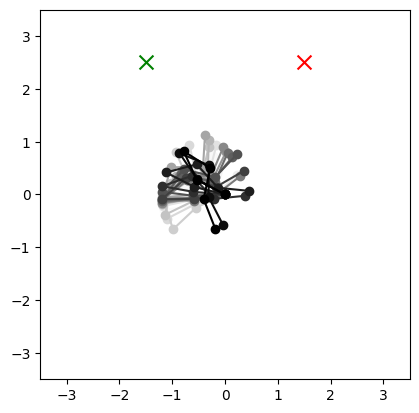

In [4]:
# Initialisation aléatoire de l'environnement
state, joints_xy, _ = reset_in_random_configuration(env)

# On simule une trajectoire de 20 steps
n_steps = 20

# Pour sauvegarder la trajectoire
traj = np.zeros((n_steps+1, env.n_dofs+1, 2))
traj[0] = joints_xy

for step in range(n_steps):

    # Action aléatoire dans [-1, 1] x [-1, 1]
    action = np.random.uniform(-np.pi/12, np.pi/12, n_joints)

    # On effectue l'action
    state, joints_xy, reward = env.step(action)

    # Sauvegarde
    traj[step+1] = joints_xy

# Affichage de la trajectoire
env.display_trajectory(traj)

## 2. Limites de Q-learning

Les cellules suivantes vous donnent une implémentation de l'algorithme Q-learning (ce qui peut vous servir de correction pour le TP précédent). 

In [5]:
def epsilon_greedy(q_values, state_id, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(0, q_values.shape[1])
    else:
        return np.argmax(q_values[state_id])

In [6]:
def q_learning(n_joints, episodes, alpha, gamma):

    # Instanciation de l'environnement
    env = Arm(
        lengths=[3/n_joints]*n_joints,
        target_position=[-1.5, 2.5],
        obstacle_position=[1.5, 2.5]
    )

    # Initialisation des Q-values
    q_values = np.zeros((24**n_joints, 3**n_joints))
    
    # Sauvegarde des récompenses par épisode
    total_rewards = []
    
    for i in tqdm(range(episodes)):

        # On utilise un "scheduler" pour l'hyperparamètre epsilon
        # ce qui permet de réduire progressivement l'exploration au cours de l'apprentissage
        # A début de l'apprentissage, epsilon vaut 1 --> que de l'exploration
        # A la fin de l'apprentissage, epsilon vaut 0.0625 --> presque que exploitation
        k = (5*i)//episodes
        epsilon = 2**(-k)
        
        # Initialisation de l'environnement
        state, _, _ = reset_in_random_configuration(env)

        # Récompense cumulée de l'épisode
        total_reward = 0
    
        # Calcul de l'état discret à partir de l'état continu
        state_id = compute_discretized_state(state)
    
        for _ in range(n_steps):

            # Politique espilon greedy
            action_id = epsilon_greedy(q_values, state_id, epsilon)
    
            # Calcul de l'action continue à partir de l'action discrète
            action = compute_continuous_action(action_id, n_joints)
            
            # Application de l'action
            next_state, _, reward = env.step(action)
            total_reward += reward
    
            # Calcul de l'état suivant discret à partir de l'état suivant continu
            next_state_id = compute_discretized_state(next_state)
    
            # Mise à jour de la Q-value
            target = reward + gamma * np.max(q_values[next_state_id])
            q_values[state_id, action_id] += alpha * \
                (target - q_values[state_id, action_id])
    
            # s <- s'
            state_id = next_state_id
    
        # Sauvegarde de la récompense totale
        total_rewards.append(total_reward)

    return q_values, total_rewards, env

On peut désormais utiliser lancer l'algorithme de Q-learning et récupérer les résultats de la manière suivante:

  0%|          | 0/5000 [00:00<?, ?it/s]

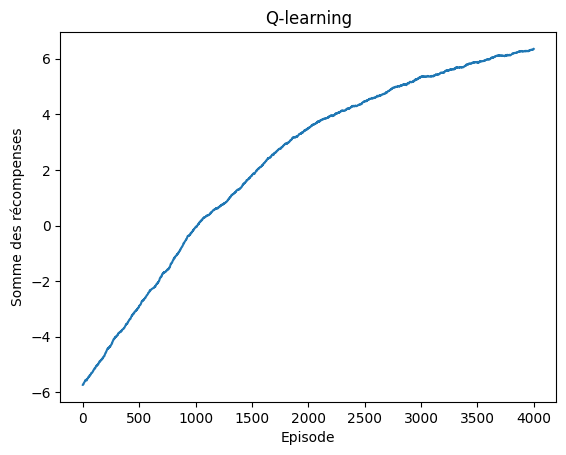

In [7]:
n_joints = 2
episodes = 5000
alpha = 0.3
gamma = 0.9

q_values, total_rewards, env = q_learning(n_joints, episodes, alpha, gamma)

moving_average_rewards = np.convolve(
    total_rewards, np.ones(1000)/1000, mode='valid')
plt.plot(moving_average_rewards)
plt.ylabel('Somme des récompenses')
plt.xlabel('Episode')
plt.title('Q-learning')
plt.show()

Pour évaluer la qualité de la politique obtenue après apprentissage, on ne peut plus se contenter de regarder sa récompense cumulée sur un seul épisode. Comme l'initalisation est aléatoire, chaque épisode peut avoir une récompense cumulée très différente. Il faut donc regarder les statistiques sur *beaucoup* d'épisodes. Pour ce TP, on propose de regarder la moyenne de récompense cumulée sur 1000 épisodes.

In [8]:
def eval_q_values(q_values, env, episodes=1000):
    total_rewards = []
    for i in range(episodes):
    
        # Initialisation de l'environnement
        state, joints_xy, reward = reset_in_random_configuration(env)
            
        # On simule une trajectoire de 20 steps avec cette politique et cet environnement
        n_steps = 20
        
        # Pour sauvegarder la trajectoire
        traj = np.zeros((n_steps+1, env.n_dofs+1, 2))
        traj[0] = joints_xy
        
        total_reward = 0
                
        for step in range(n_steps):
        
            # Calcul de l'état discret à partir de l'état continu
            state_id = compute_discretized_state(state)
    
            # Calcul de l'action discrete par politique greedy
            # greedy = epsilon greedy avec epsilon = 0
            action_id = epsilon_greedy(q_values, state_id, 0.)
    
            # Calcul de l'action continue à partir de l'action discrète
            action = compute_continuous_action(action_id, n_joints)
    
            # Application de l'action
            state, joints_xy, reward = env.step(action)
            total_reward += reward
        
            # Sauvegarde
            traj[step+1] = joints_xy
    
        total_rewards.append(total_reward)

    return np.mean(total_rewards)

print(f"Moyenne sur 1000 épisodes: {eval_q_values(q_values, env)}")

Moyenne sur 1000 épisodes: 7.223949059494626


In [9]:
r = np.sum(q_values != 0).item() / (q_values.shape[0] * q_values.shape[1])
print(f"Pourcentage de Q-values modifiées au moins une fois : {100*r:.2f} %")

Pourcentage de Q-values modifiées au moins une fois : 99.94 %


#### Question 1.

Tracez sur une figure la récompense cumulée moyenne obtenue après entraînement, en fonction du nombre d'articulation du bras $n \in [1, 5]$.

Sur une deuxième figure, tracez l'évolution du pourcentage de Q-values explorées toujours en fonction du nombre d'articulation.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Définition des hyperparamètres
episodes = 5000
alpha = 0.3
gamma = 0.9

liste_n_joints = [1, 2, 3, 4, 5]
recompenses_moyennes = []
pourcentages_exploration = []

for n in liste_n_joints:
    # --- LA CORRECTION EST ICI ---
    # On met à jour la variable globale pour que eval_q_values l'utilise correctement
    n_joints = n 
    
    print(f"\n--- Entraînement pour n_joints = {n_joints} ---")
    
    # 1. Entraînement avec Q-learning
    q_values, total_rewards, env = q_learning(n_joints, episodes, alpha, gamma)
    
    # 2. Évaluation de la politique sur 1000 épisodes
    mean_reward = eval_q_values(q_values, env, episodes=1000)
    recompenses_moyennes.append(mean_reward)
    print(f"Récompense moyenne obtenue : {mean_reward}")
    
    # 3. Calcul du pourcentage de Q-values explorées
    total_q_values = q_values.shape[0] * q_values.shape[1]
    explored_q_values = np.sum(q_values != 0)
    pourcentage = (explored_q_values / total_q_values) * 100
    pourcentages_exploration.append(pourcentage)
    print(f"Pourcentage exploré : {pourcentage:.4f} %")


--- Entraînement pour n_joints = 1 ---


  0%|          | 0/5000 [00:00<?, ?it/s]

Récompense moyenne obtenue : 7.134559037048589
Pourcentage exploré : 100.0000 %

--- Entraînement pour n_joints = 2 ---


  0%|          | 0/5000 [00:00<?, ?it/s]

Récompense moyenne obtenue : 7.063749779715007
Pourcentage exploré : 99.9421 %

--- Entraînement pour n_joints = 3 ---


...

Récompense moyenne obtenue : -2.3190285731387212
Pourcentage exploré : 21.9045 %

--- Entraînement pour n_joints = 4 ---


  0%|          | 0/5000 [00:00<?, ?it/s]

Récompense moyenne obtenue : -6.066978082317774
Pourcentage exploré : 0.3708 %

--- Entraînement pour n_joints = 5 ---


  0%|          | 0/5000 [00:00<?, ?it/s]

Récompense moyenne obtenue : -6.172225858796575
Pourcentage exploré : 0.0052 %


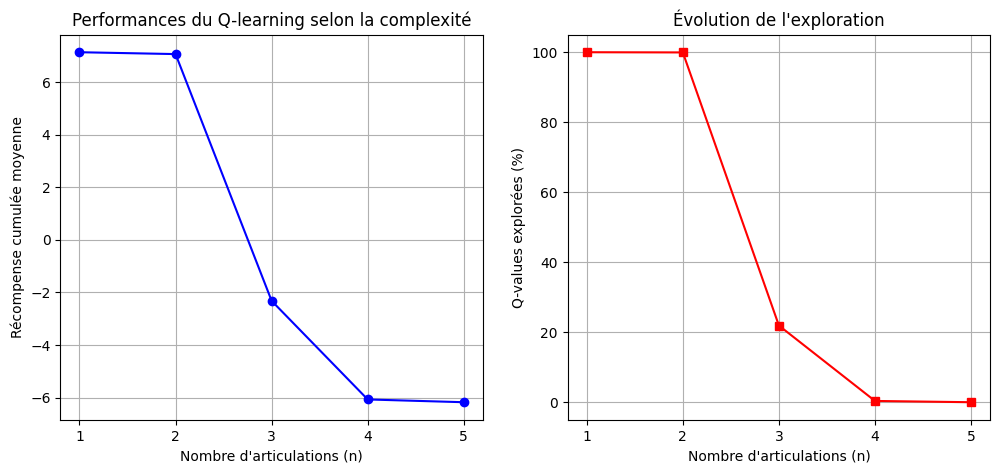

In [11]:
# --- Affichage des graphiques ---
plt.figure(figsize=(12, 5))

# Première figure : Récompense cumulée moyenne
plt.subplot(1, 2, 1)
plt.plot(liste_n_joints, recompenses_moyennes, marker='o', color='b')
plt.xlabel("Nombre d'articulations (n)")
plt.ylabel("Récompense cumulée moyenne")
plt.title("Performances du Q-learning selon la complexité")
plt.grid(True)
plt.xticks(liste_n_joints)

# Deuxième figure : Pourcentage de Q-values explorées
plt.subplot(1, 2, 2)
plt.plot(liste_n_joints, pourcentages_exploration, marker='s', color='r')
plt.xlabel("Nombre d'articulations (n)")
plt.ylabel("Q-values explorées (%)")
plt.title("Évolution de l'exploration")
plt.grid(True)
plt.xticks(liste_n_joints)

plt.show()

#### Question 2.

(Pour ce genre de question, réfléchissez aux réponses et débriefez avec votre chargé.e de TP)

Commentez les résultats:
- Qu'est-ce que vous observez ?
- Comment expliquer ces observations ?

Concluez quant aux limites du Q-learning.

Pourquoi utiliser un réseau de neurones pour prédire les Q-values associée chaque paire $(s, a)$ pourrait mieux fonctionner ?


## 3. Deep Q-learning (ou Deep Q Network - DQN)

Dans cette partie nous allons implémenter l'algorithme DQN. L'idée générale de l'algorithme est d'utiliser un réseau de neurones pour approximer la fonction $Q(s, a)$. Le réseau de neurones prend en entrée un vecteur décrivant l'état $s$ de l'agent, et donne en sortie un vecteur de dimension $n_a$ dont chaque valeur correspond à l'estimation de $Q(s, a)$.

En pratique, deux autres techniques sont nécessaires pour que ça fonctionne bien:
- *Experience Replay*: Le réseau doit être entraîné sur des batchs échantillonés aléatoirement parmis l'historique récent des transitions récoltées. Pour implémenter cette idée, on va définir une structure de données appelée *Replay Buffer* qui stocke des transitions récentes dans un buffer. Les nouvelles transitions récoltées sont ajoutées, et les plus anciennes sont retirées.

- *Target Network*: la fonction de coût dans le Deep Q-learning compare deux estimations de Q-values différentes. Cette double utilisation peut être source d'instabilité dans l'apprentissage. En pratique, l'apprentissage est plus stable lorsqu'on utilise un deuxième réseau de neurones appelé *Target Network* qui sert à donner la deuxième estimation. Ce réseau n'est pas entraîné directement par descente de gradient, mais à intervalle régulier, on va venir copier les poids de notre réseau principal dans ce nouveau réseau, pour que ses prédictions s'améliorent quand même au cours du temps.

Pour l'implémentation des réseaux de neurones et leur entraînement, nous allons utiliser à nouveau Pytorch:

In [12]:
import torch
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

### 3.1. Implémentation du Replay Buffer

#### Question 3.

Complétez l'implémentation de la classe ReplayBuffer:
- Le replay buffer doit posséder comme attributs un tenseur (torch.tensor) pour les états $s$, un pour les actions $a$, un pour les récompenses $r$ et un pour les états suivants $s'$.

- La méthode `insert` doit ajouter la nouvelle transition. Si le buffer est déjà rempli, cela doit venir écraser la transition la plus ancienne dans le buffer. L'implémentation la plus simple consiste à garder comme attribut `current_id` l'indice du prochain élément à écraser. Cet attribut commence à 0, et à chaque nouvel ajout on l'incrémente, en revenant à 0 lorsqu'on atteint la limite du buffer.

- La méthode `sample` doit échantilloner `batch_size` éléments dans le buffer, et les retourner sous forme de tuple.

In [13]:
class ReplayBuffer:
    def __init__(self, max_size, state_dim):
        
        # Taille maximale
        self.max_size = max_size

        # Taille courante (utile pour échantilloner si on n'a pas encore rempli le buffer)
        self.size = 0

        # Index de la prochaine insertion
        self.current_id = 0

        # Données stockées
        self.states = torch.zeros(max_size, state_dim, dtype=torch.float32)
        self.actions = torch.zeros(max_size, 1, dtype=torch.long)
        self.rewards = torch.zeros(max_size, 1, dtype=torch.float32)
        self.next_states = torch.zeros(max_size, state_dim, dtype=torch.float32)

    def insert(self, state, action, reward, next_state):
        # Ajouter les nouvelles données
        self.states[self.current_id] =  state
        self.actions[self.current_id] = action
        self.rewards[self.current_id] = reward
        self.next_states[self.current_id] = next_state

        # Mettre à jour l'index de la prochaine insertion (ne pas oublier de revenir à si on dépasse)
        self.current_id = (self.current_id + 1) % self.max_size

        # Mettre à jour la taille (sans dépasser max_size)
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        ids = np.random.randint(0, self.size, size=batch_size)
        return (
            self.states[ids],
            self.actions[ids],
            self.rewards[ids],
            self.next_states[ids],
        )

In [14]:
# Pour tester votre implémentation

r = ReplayBuffer(10, 5)
for i in range(11):
    r.insert(torch.zeros(5), i, 0, torch.zeros(5))

print(r.actions[0])  # Doit afficher tensor([10])
print(r.current_id) # Doit afficher 1

tensor([10])
1


### 3.2. Représentation de l'état

Pour que le réseau de neurones généralise bien, on peut lui faciliter la tâche en lui donnant en entrée un vecteur avec des features facilement exploitables pour l'apprentissage.

Par exemple, si on donnait à notre réseau un vecteur one-hot donnant juste l'indice de l'état, l'apprentissage serait plus difficile que si on donnait un vecteur donnant les coordonnées angulaires des articulations du bras robotique. En effet avec les coordonnées angulaires du bras robotique, le réseau va pouvoir généraliser facilement: deux positions angulaires proches vont probablement correspondre à des Q-values proches. C'est cette capacité de généralisation qui démarque DQN du Q-learning sans réseau de neurones.

La fonction `prepare_state` ci-dessous permet de construire des entrées de la forme: [$\cos(\theta_1), \sin(\theta_1), \cos(\theta_2), \sin(\theta_2), \dots$] pour décrire les configurations du bras.

L'utilisation de fonctions trigonométriques sert à conserver la continuité des descriptions. On veut qu'un état correspondant à $\theta_1$ légèrement supérieur à 0 soit vu commme "proche" par le réseau de neurones d'un état correspondant à $\theta_1$ légèrement inférieur à $2\pi$. Cette continuité est assurée par l'utilisation de $\cos$ et $\sin$. Ca fonctionnerait également sans utiliser ces fonctions, mais ça fonctionnerait moins bien.

In [15]:
def prepare_state(np_state):
    state = torch.FloatTensor(np_state)
    if len(state.shape) == 1:
        state = state.unsqueeze(0)
    return torch.concat([torch.cos(state), torch.sin(state)], axis=1)

### 3.3. Réseau de neurones

Pour la tâche sur laquelle on travaille, pas besoin d'un très gros réseau de neurones. On se contentera d'un MLP avec deux ou trois couches.

#### Question 3.

Complétez dans la cellule suivante la définition de la classe `QNetwork`. Le réseau de neurones doit être un MLP de deux ou trois couches.

In [28]:
class QNetwork(torch.nn.Module):

    def __init__(self, state_dim, hidden_dim, action_dim):
        torch.nn.Module.__init__(self)

        self.linear1 = torch.nn.Linear(state_dim, hidden_dim)
        self.linear2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = torch.nn.Linear(hidden_dim, action_dim)

        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        

    def forward(self, x):
        
        x = self.linear1(x)
        #x = self.bn1(x)
        x = torch.relu(x)

        x = self.linear2(x)
        #x = self.bn2(x)
        x = torch.relu(x)

        x = self.linear3(x)

        return x

### 3.4. Fonction de coût

La fonction de coût pour DQN est la suivante:

$\mathcal L(s, a, r, s') = \big(r + \gamma \max_{a'}Q_{target}(s', a') - Q(s, a) \big)^2$

Dans cette expression, $Q_{target}$ désigne le *Target Network*, $Q$ désigne le réseau qu'on entraîne, et ($s, a, r, s'$) la transition sur laquelle on s'entraîne (donnée par le Replay Buffer).

#### Question 4.

Complétez dans la cellule suivante la définition de la fonction `q_learning_loss` permettant d'effectuer le calcul donné dans la formule ci-dessus pour un batch de transition échantilloné par le replay buffer.

In [29]:
def deep_q_learning_loss(q_network, target_network, state, action_id, reward, next_state, gamma):

    # Calcul de Q(s, a)
    predicted_q_value = q_network(state)

    # .gather(1, action_id) permet de réaliser l'opération [action_id] dans
    # le cas où action_id est un tenseur d'indices et pas juste un indice
    # Ca retourne un tenseur de dimension (batch_size, 1) contenant Q(s, a)
    predicted_q_value = predicted_q_value.gather(1, action_id)

    # Calcul de max_a' Q_target(s', a')
    target_q_values = target_network(next_state)
    target_max, _ = torch.max(target_q_values, axis=1, keepdim=True)  # Keepdim permet de garder la dimension (batch_size, 1)
    target_q_value = reward + gamma * target_max

    # Calcul de la loss
    return torch.nn.MSELoss()(predicted_q_value, target_q_value)

In [30]:
# Pour tester votre fonction
q_network = QNetwork(5, 3, 10)

loss = deep_q_learning_loss(
    q_network, 
    q_network, 
    state=torch.zeros(3, 5), 
    action_id=torch.zeros(3, 1, dtype=torch.long), 
    reward=torch.zeros(3, 1), 
    next_state=torch.zeros(3, 5), 
    gamma=gamma)

# Doit afficher tensor(xxxx, grad_fn=<MseLossBackward0>)
# où xxxx est une valeur float
print(loss)

tensor(0.2627, grad_fn=<MseLossBackward0>)


La cellule suivante définit les hyperparamètres de l'algorithme. Ca devrait assez bien fonctionner avec les hyperparamètres donnés ici.

In [31]:
# Paramètres de l'environnement
n_joints = 4
state_dim = 2 * n_joints
action_dim = 3 ** n_joints

# Nombre d'épisodes (pour une comparaison juste avec Q-learning, on garde 5000)
episodes = 5_000
total_steps = n_steps * episodes

# Hyperparamètres pour l'entraînement du réseau de neurones
hidden_dim = 32
batch_size = 32
learning_rate = 1e-3

# Taille du replay buffer
replay_buffer_size = 10_000

# Nombre d'étapes sans apprentissage où on se contente remplir le replay buffer
warmup_steps = 1_000

# Fréquence à laquelle on met à jour le target network en copiant les poids du réseau
target_network_update_frequency = 1_000

#### Question 5.

Complétez la boucle d'apprentissage dans la cellule suivante.

Par rapport à de l'apprentissage supervisé, les données ne proviennent pas d'un dataset mais de l'interaction avec l'environnement, la distribution des donnés évolue au fûr et à mesure que la politique s'améliore. A chaque pas de la boucle d'apprentissage, on va:

1. Générer des nouvelles données avec la politique epsilon-greedy se basant sur le réseau de neurones actuel, qu'on va ajouter au Replay Buffer
2. Faire une itération d'entraînement du réseau de neurones sur un batch échantilloné depuis le Replay Buffer

In [32]:
# Initialisation du Replay Buffer
replay_buffer = ReplayBuffer(replay_buffer_size, state_dim)

# Initialisation de l'environnement
env = Arm(
    lengths=[3/n_joints]*n_joints,
    target_position=[-1.5, 2.5],
    obstacle_position=[1.5, 2.5]
)

# Initialisation du Q-Network qu'on va entraîner
q_network = QNetwork(state_dim, hidden_dim, action_dim)

# Initialisation du target network qui va être une sauvegarde du q_network
target_network = QNetwork(state_dim, hidden_dim, action_dim)
target_network.load_state_dict(q_network.state_dict())  # Permet de copier les poids du réseau

# Initialisation de l'optimiseur
optimizer = torch.optim.Adam(q_network.parameters(), lr=learning_rate)

# Pour tracer l'évolution des récompenses au cours du temps
total_rewards = []

for step in tqdm(range(total_steps)):

    # Comme pour Q-learning, on utiliser un scheduler pour epsilon
    k = (5*step)//total_steps
    epsilon = 2**(-k)

    # Tous les n_steps, on réinitialise l'environnement
    if step % n_steps == 0:

        # Sauvegarde de la récompense totale de l'épisode précédent
        if step > 0:
            total_rewards.append(total_reward)
            
        # Réinitialisation de l'environnement
        state, _, _ = reset_in_random_configuration(env)
        total_reward = 0

    # ======================= 1. Générer des nouvelles données =====================

    # no_grad permet de ne pas calculer les gradients lorsqu'on utilise
    # le réseau uniquement en mode "inférence" et pas pour l'entraîner
    with torch.no_grad():

        # On prépare le tenseur qui correspond à l'état
        torch_state = prepare_state(state)

        # Politique epsilon-greedy
        if np.random.rand() < epsilon:
            # Action aléatoire
            action_id = np.random.randint(0, 3**4)
        else:
            # Utilisation du réseau en mode inférence
            torch_action = q_network(torch_state)
            action_id = torch.argmax(torch_action, axis=1).item()

        # Calcul de l'action continue à partir de l'action discrète
        action = compute_continuous_action(action_id, n_joints)

    # Application de l'action
    next_state, _, reward = env.step(action)
    total_reward += reward
    torch_next_state = prepare_state(next_state)

    # Insertion dans le replay buffer
    replay_buffer.insert(torch_state, action_id, reward, torch_next_state)

    # s <- s'
    state = next_state

    # ======================= 2. Entraîner le réseau sur un échantillon =====================

    # On commence seulement après une période de "warmup" pour remplir un peu le replay buffer
    if step > warmup_steps:  
        
        # 1. Échantillonner un batch depuis le Replay Buffer
        batch_states, batch_actions, batch_rewards, batch_next_states = replay_buffer.sample(batch_size)
        
        # 2. Calculer la loss
        loss = deep_q_learning_loss(
            q_network=q_network, 
            target_network=target_network, 
            state=batch_states, 
            action_id=batch_actions, 
            reward=batch_rewards, 
            next_state=batch_next_states, 
            gamma=gamma
        )
        
        # 3. Réinitialiser les gradients
        optimizer.zero_grad()
        
        # 4. Rétropropagation (calcul des gradients)
        loss.backward()
        
        # 5. Mise à jour des poids du réseau
        optimizer.step()

    # Périodiquement on met à jour le target network en recopiant les poids du q_network
    if step % target_network_update_frequency == 0:
        target_network.load_state_dict(q_network.state_dict())


  0%|          | 0/100000 [00:00<?, ?it/s]

La cellule suivante permet d'afficher l'évolution de la somme des récompenses au cours du temps.

Si votre algorithme fonctionne bien, vous devriez avoir une courbe croissante qui atteint environ 2 pour les hyperparamètres donnés dans l'énoncé.

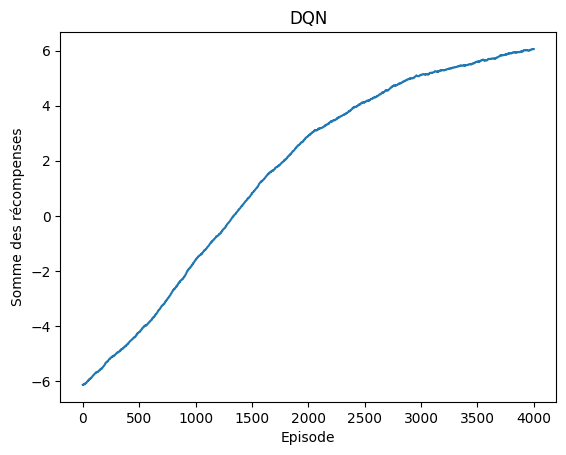

In [33]:
moving_average_rewards = np.convolve(
    total_rewards, np.ones(1000)/1000, mode='valid')
plt.plot(moving_average_rewards)
plt.ylabel('Somme des récompenses')
plt.xlabel('Episode')
plt.title('DQN')
plt.show()

Pour évaluer la qualité de la politique obtenue après apprentissage, il faut à nouveau regarder les statistiques sur *beaucoup* d'épisodes.

#### Question 6.

Complétez la cellule suivante permettant d'évaluer la politique apprise.

Lancez la cellule et comparez les résultats obtenus à ceux qu'on avait obtenu avec Q-learning pour le même nombre d'articulations.

In [34]:
total_rewards = []

for i in range(1000):

    # Initialisation de l'environnement
    state, joints_xy, reward = reset_in_random_configuration(env)
    total_reward = 0
    
    with torch.no_grad():
        
        for step in range(n_steps):
        
            # Politique greedy avec le q network
            # 1. On prépare l'état pour qu'il soit compréhensible par le réseau
            torch_state = prepare_state(state)
            
            # 2. On demande au réseau de prédire les Q-values pour cet état
            q_values_pred = q_network(torch_state)
            
            # 3. On sélectionne l'action avec la plus grande Q-value (Greedy)
            action_id = torch.argmax(q_values_pred, axis=1).item()
        
            # Calcul de l'action continue à partir de l'action discrète
            action = compute_continuous_action(action_id, n_joints)
    
            # Application de l'action
            state, joints_xy, reward = env.step(action)
            total_reward += reward
            
    total_rewards.append(total_reward)

print(f"Moyenne sur 1000 épisodes: {np.mean(total_rewards)}")

Moyenne sur 1000 épisodes: 6.824222112681413
